# 基于身高与体重的贝叶斯分类器设计
## 模式识别第一次作业

作业任务：
给定二维向量 $\mathbf{x}=(\text{身高},\text{体重})^\mathsf{T}$，估计样本属于女生还是男生。
其中，身高单位为`cm`，体重单位为`kg`；类别编码为`女生-0、男生-1`。

实验流程依次为：数据清洗与划分、直方图绘制、PDF（最大似然估计、贝叶斯估计）、最小错误率决策、测试评估和可交互的预测。
贝叶斯分类器使用MLE估计参数的二维联合高斯分布。

In [35]:
import os
for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[variable] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.lines import Line2D
from IPython.display import display, Markdown, clear_output
import ipywidgets as widgets

%matplotlib inline

DATA_PATH = "pattern_recognition_homework_dataset.xlsx"

SEED = 23
TEST_RATIO = 0.20
FEATURES = ["身高(cm)", "体重(kg)"]
CLASSES = np.array([0, 1])
CLASS_NAMES = {0: "女生", 1: "男生"}
COLORS = {0: "#A34D91", 1: "#167D9A"}
REGION_COLORS = ["#F5EAF2", "#E7F3F7"]
PROBABILITY_CMAP = LinearSegmentedColormap.from_list("gender_posterior", [COLORS[0], "#F8F9FA", COLORS[1]])

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC", "Arial Unicode MS"]
font_name = next((name for name in font_candidates if name in available_fonts), "DejaVu Sans")
plt.rcParams.update({
    "font.family": font_name, "axes.unicode_minus": False,
    "figure.dpi": 115,
    "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.17, "axes.axisbelow": True,
})
pd.set_option("display.max_columns", 16)
pd.set_option("display.float_format", "{:.5f}".format)

def show_table(frame, precision=4):
    display(frame.style.format(precision=precision).hide(axis="index"))

def show_figure(figure):
    plt.show()
    plt.close(figure)

print(f"测试集比例 {TEST_RATIO} , 随机种子 {SEED}")

测试集比例 0.2 , 随机种子 23


### 1. 数据读取、清洗与划分

首先读取性别、身高和体重以及编号内容。过程中排除性别不为 0/1、身高或体重缺失或无效的记录。

随后处理极端离群点：在男女两类内分别计算四分位数：任一特征落在 $[Q_1-3\,IQR,\ Q_3+3\,IQR]$ 之外时，整条记录按极端离群样本排除，其中 $IQR=Q_3-Q_1$。

In [36]:
raw = pd.read_excel(DATA_PATH, usecols=["编号", "性别 男1女0", *FEATURES])
data = raw.rename(columns={"性别 男1女0": "性别"}).copy()
data["性别"] = pd.to_numeric(data["性别"], errors="coerce")
data[FEATURES] = data[FEATURES].apply(pd.to_numeric, errors="coerce")

valid_label = data["性别"].isin(CLASSES)
valid_features = np.isfinite(data[FEATURES]).all(axis=1) & data[FEATURES].gt(0).all(axis=1)

valid_mask = valid_label & valid_features
valid = data.loc[valid_mask].copy()
keep = pd.Series(True, index=valid.index)

bounds_rows = []
for label in CLASSES:
    group = valid.loc[valid["性别"] == label]
    for feature in FEATURES:
        q1, q3 = group[feature].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 3 * iqr, q3 + 3 * iqr
        bounds_rows.append({"类别": CLASS_NAMES[label], "特征": feature,
                            "Q1": q1, "Q3": q3, "IQR": iqr, "下界": lower, "上界": upper})
        keep.loc[group.index] &= group[feature].between(lower, upper)

clean = valid.loc[keep].copy().reset_index(drop=True)
clean["性别"] = clean["性别"].astype(int)
bounds_table = pd.DataFrame(bounds_rows)

show_table(pd.DataFrame({
    "项目": ["原始样本", "性别或特征无效", "极端离群", "保留样本", "女生保留样本", "男生保留样本"],
    "数量": [len(raw), int((~valid_mask).sum()),
             len(valid) - len(clean), len(clean), int(clean["性别"].eq(0).sum()), int(clean["性别"].eq(1).sum())]
}), 0)
display(Markdown("**极端离群判定范围**"))
show_table(bounds_table, 2)

项目,数量
原始样本,1280
性别或特征无效,7
极端离群,7
保留样本,1266
女生保留样本,252
男生保留样本,1014


**极端离群判定范围**

类别,特征,Q1,Q3,IQR,下界,上界
女生,身高(cm),160.00,167.00,7.00,139.00,188.00
女生,体重(kg),48.00,55.00,7.00,27.00,76.00
男生,身高(cm),170.00,179.00,9.00,143.00,206.00
男生,体重(kg),61.50,75.00,13.50,21.00,115.50


随后进行数据集划分，比例在初始化中确定，按训练集：测试集=80%：20%的比例划分。

In [37]:
rng = np.random.default_rng(SEED)
train_indices, test_indices = [], []
for label in CLASSES:
    indices = clean.index[clean["性别"].eq(label)].to_numpy()
    shuffled = rng.permutation(indices)
    n_test = max(1, int(round(len(shuffled) * TEST_RATIO)))
    test_indices.extend(shuffled[:n_test])
    train_indices.extend(shuffled[n_test:])

train = clean.loc[rng.permutation(train_indices)].reset_index(drop=True)
test = clean.loc[rng.permutation(test_indices)].reset_index(drop=True)
X_train, y_train = train[FEATURES].to_numpy(float), train["性别"].to_numpy(int)
X_test, y_test = test[FEATURES].to_numpy(float), test["性别"].to_numpy(int)
assert set(train["编号"]).isdisjoint(test["编号"])
assert len(train) + len(test) == len(clean)

split_table = pd.DataFrame([
    {"类别": CLASS_NAMES[label], "全部": int(clean["性别"].eq(label).sum()),
     "训练集": int(train["性别"].eq(label).sum()), "测试集": int(test["性别"].eq(label).sum())}
    for label in CLASSES
])
split_table.loc[len(split_table)] = ["合计", len(clean), len(train), len(test)]
show_table(split_table, 0)

类别,全部,训练集,测试集
女生,252,202,50
男生,1014,811,203
合计,1266,1013,253


### 2. 男女生身高、体重的直方图

横轴为特征值，纵轴为概率密度。身高箱宽为 2cm，体重箱宽为 5kg。

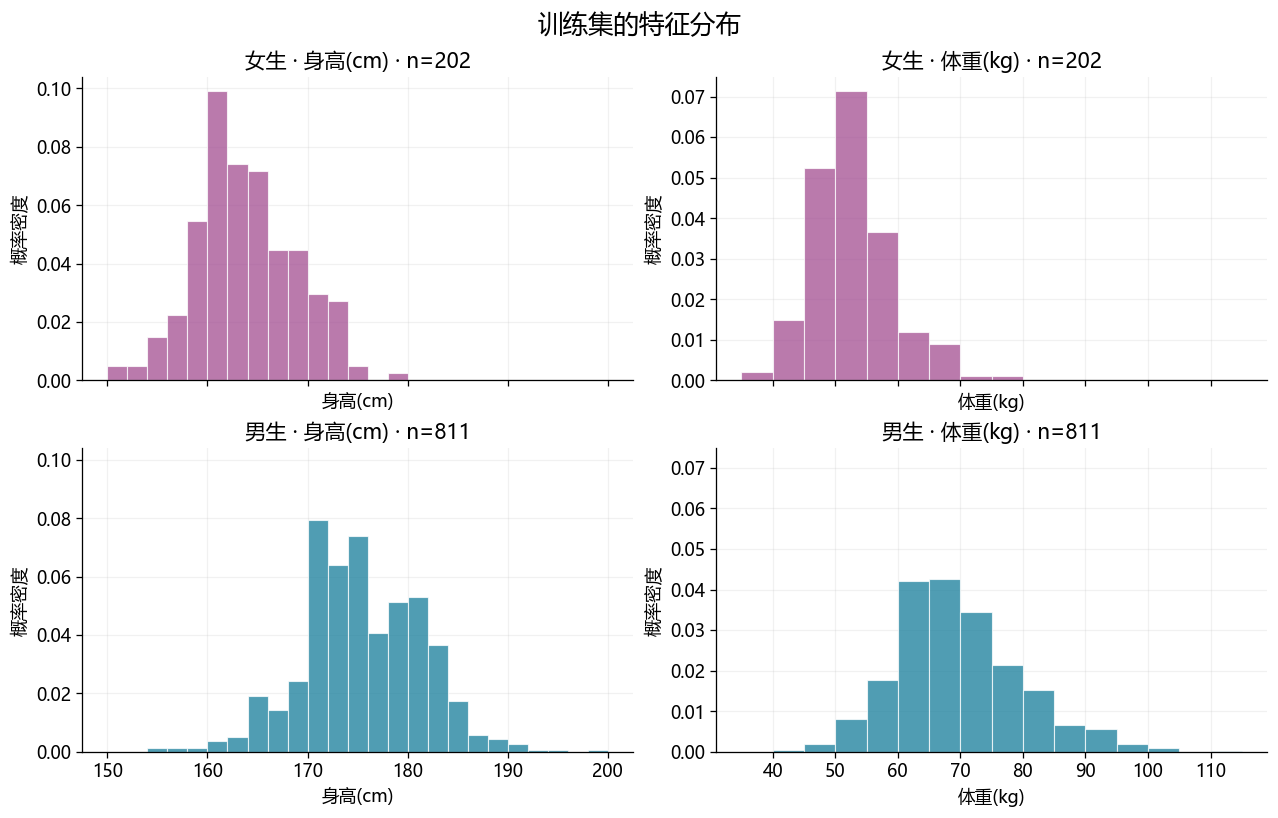

In [38]:
bins = {}
for feature, width in zip(FEATURES, [2, 5]):
    start = np.floor(train[feature].min() / width) * width
    stop = np.ceil(train[feature].max() / width) * width + width
    bins[feature] = np.arange(start, stop + width / 2, width)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex="col", sharey="col", layout="constrained")
for row, label in enumerate(CLASSES):
    group = train.loc[train["性别"].eq(label)]
    for col, feature in enumerate(FEATURES):
        ax = axes[row, col]
        ax.hist(group[feature], bins=bins[feature], density=True,
                color=COLORS[label], alpha=0.75, edgecolor="white", linewidth=0.7)
        ax.set(title=f"{CLASS_NAMES[label]} · {feature} · n={len(group)}", xlabel=feature, ylabel="概率密度")
fig.suptitle("训练集的特征分布", fontsize=16)
show_figure(fig)

### 3. 最大似然估计（MLE）

对于类别 $k$ 的 $n_k$ 个样本，假设 $\mathbf{x}\mid\omega_k\sim\mathcal N_2(\boldsymbol\mu_k,\boldsymbol\Sigma_k)$。
最大化对数似然后得到：

$$\widehat{\boldsymbol\mu}_k=\frac1{n_k}\sum_{i=1}^{n_k}\mathbf{x}_i,\qquad
\widehat{\boldsymbol\Sigma}_k=\frac1{n_k}\sum_{i=1}^{n_k}
(\mathbf{x}_i-\widehat{\boldsymbol\mu}_k)(\mathbf{x}_i-\widehat{\boldsymbol\mu}_k)^\mathsf T.$$

协方差矩阵的两个主对角线元素分别为身高、体重的方差，非对角元素为它们的相关关系。各特征的边缘密度为：

$$p(x_j\mid\omega_k)=\frac{1}{\sqrt{2\pi\widehat\sigma_{kj}^{2}}}
\exp\left[-\frac{(x_j-\widehat\mu_{kj})^2}{2\widehat\sigma_{kj}^{2}}\right].$$

类别,特征,样本数,均值 MLE,方差 MLE
女生,身高(cm),202,163.2426,25.0550
女生,体重(kg),202,51.7871,36.9522
男生,身高(cm),811,174.8567,35.4751
男生,体重(kg),811,68.4295,99.4808


类别,身高方差,身高-体重协方差,体重方差,相关系数,类别先验
女生,25.0550,15.8363,36.9522,0.5205,0.1994
男生,35.4751,31.6154,99.4808,0.5322,0.8006


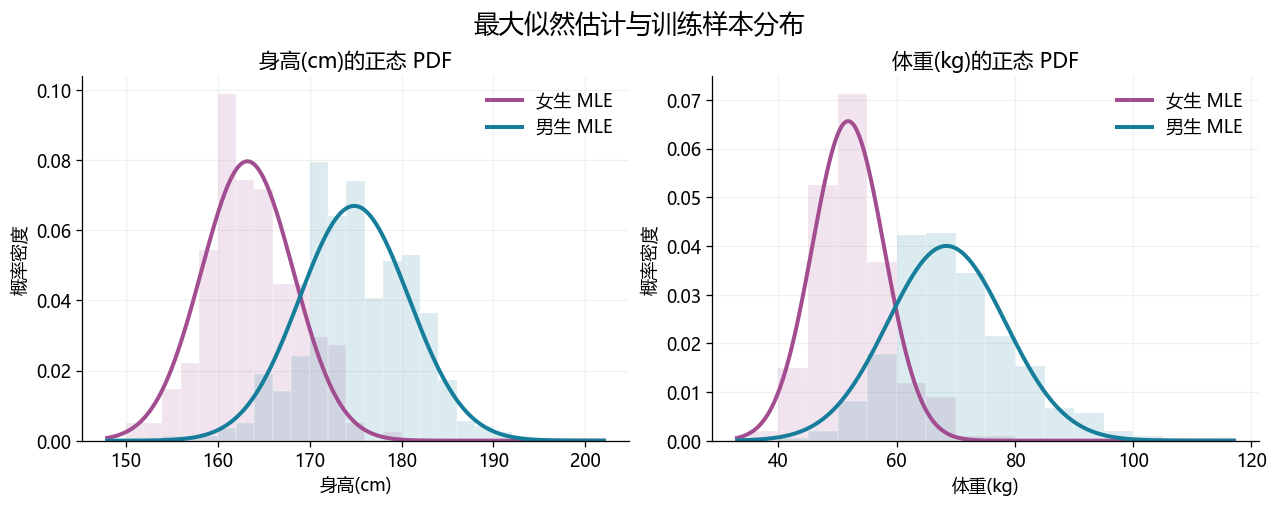

In [39]:
mle = {}
parameter_rows, covariance_rows = [], []
for label in CLASSES:
    samples = X_train[y_train == label]
    n = len(samples)
    mean = samples.mean(axis=0)
    centered = samples - mean
    covariance = centered.T @ centered / n
    prior = n / len(X_train)
    mle[int(label)] = {"n": n, "mean": mean, "covariance": covariance, "prior": prior}
    for j, feature in enumerate(FEATURES):
        parameter_rows.append({"类别": CLASS_NAMES[label], "特征": feature, "样本数": n,
                               "均值 MLE": mean[j], "方差 MLE": covariance[j, j]})

    covariance_rows.append({"类别": CLASS_NAMES[label], "身高方差": covariance[0, 0],
                            "身高-体重协方差": covariance[0, 1], "体重方差": covariance[1, 1],
                            "相关系数": covariance[0, 1] / np.sqrt(covariance[0, 0] * covariance[1, 1]),
                            "类别先验": prior})

mle_table = pd.DataFrame(parameter_rows)
show_table(mle_table)
show_table(pd.DataFrame(covariance_rows))

def normal_pdf(x, mean, variance):
    x = np.asarray(x, dtype=float)
    return np.exp(-0.5 * (x - mean) ** 2 / variance) / np.sqrt(2 * np.pi * variance)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), layout="constrained")
for j, feature in enumerate(FEATURES):
    ax = axes[j]
    grid = np.linspace(bins[feature][0] - 2, bins[feature][-1] + 2, 500)
    for label in CLASSES:
        model = mle[int(label)]
        ax.hist(train.loc[train["性别"].eq(label), feature], bins=bins[feature], density=True,
                color=COLORS[label], alpha=0.15, edgecolor="white")
        ax.plot(grid, normal_pdf(grid, model["mean"][j], model["covariance"][j, j]),
                color=COLORS[label], lw=2.5, label=f"{CLASS_NAMES[label]} MLE")
    ax.set(title=f"{feature}的正态 PDF", xlabel=feature, ylabel="概率密度")
    ax.legend(frameon=False)
fig.suptitle("最大似然估计与训练样本分布", fontsize=16)
show_figure(fig)

### 4. 贝叶斯估计（BE）

按照方差已知、均值未知的情况，对每类的每个特征分别计算。
设观测方差为 $\sigma^2$，均值的先验服从 $\mu\sim\mathcal N(\mu_0,\tau_0^2)$：

| 特征 | 先验均值 $\mu_0$ | 先验标准差 $\tau_0$ |
|:---|---:|---:|
| 身高 | 170 cm | 20 cm |
| 体重 | 65 kg | 20 kg |

男女使用同一组先验参数。由正态似然与正态先验的乘积，得到：

$$\mu\mid D\sim\mathcal N(\mu_n,\tau_n^2)$$

平方误差准则下，贝叶斯估计为后验均值 $\widehat\mu_{\mathrm{BE}}=\mu_n$。
将其代入特征 PDF：$p_{\mathrm{BE}}(x)=\mathcal N(x;\mu_n,\sigma^2)$。


类别,特征,先验均值,先验标准差,观测方差,均值 MLE,均值 BE,均值后验标准差
女生,身高(cm),170.000000,20.000000,25.055019,163.242574,163.244669,0.352131
女生,体重(kg),65.000000,20.000000,36.952211,51.787129,51.793169,0.427607
男生,身高(cm),170.000000,20.000000,35.475081,174.856720,174.856189,0.209135
男生,体重(kg),65.000000,20.000000,99.480845,68.429470,68.428418,0.350181


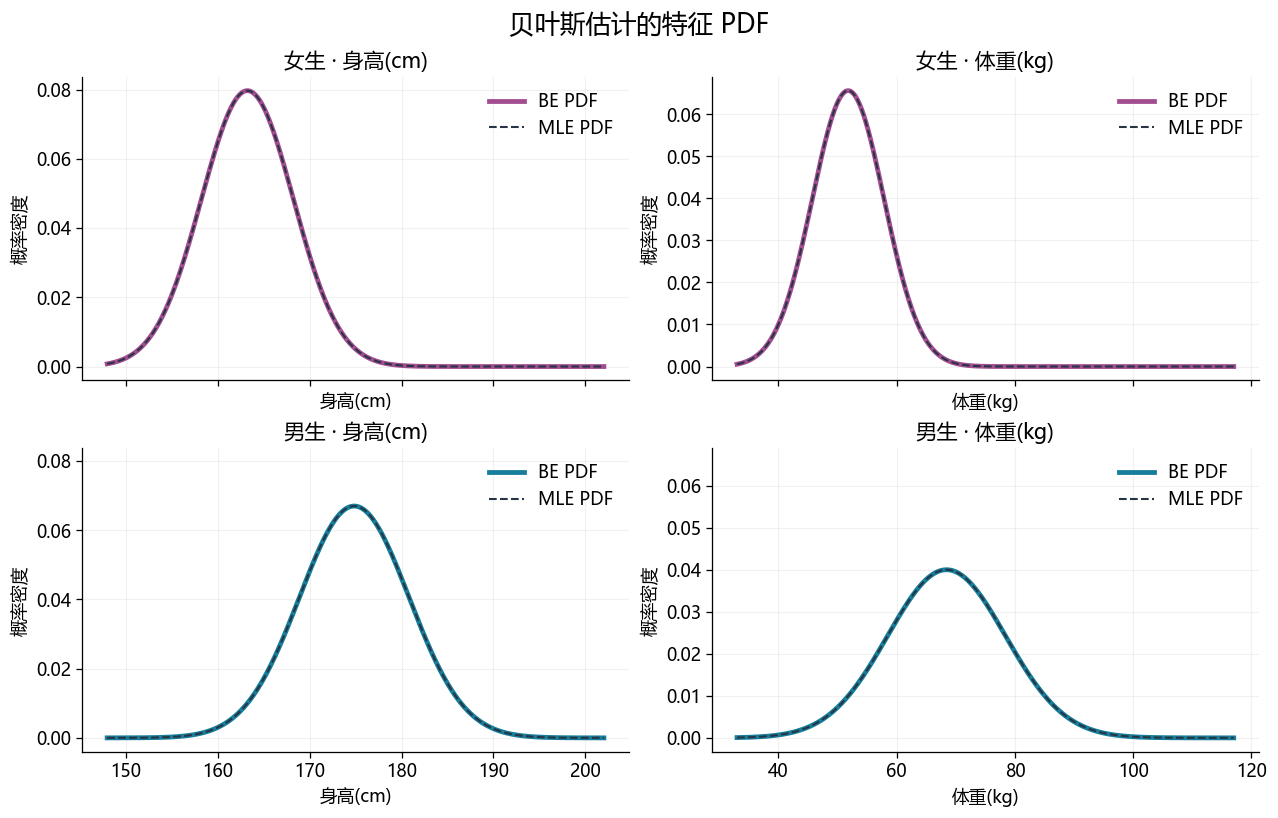

In [40]:
prior_mean = np.array([170.0, 65.0])
prior_variance = np.array([20.0 ** 2, 20.0 ** 2])
bayes_parameters = {}
bayes_rows = []
for label in CLASSES:
    model = mle[int(label)]
    n = model["n"]
    known_variance = np.diag(model["covariance"])
    posterior_variance = 1.0 / (n / known_variance + 1.0 / prior_variance)
    posterior_mean = posterior_variance * (n * model["mean"] / known_variance + prior_mean / prior_variance)
    bayes_parameters[int(label)] = {"mean": posterior_mean, "known_variance": known_variance,
                                     "mean_posterior_variance": posterior_variance}
    for j, feature in enumerate(FEATURES):
        bayes_rows.append({"类别": CLASS_NAMES[label], "特征": feature,
                          "先验均值": prior_mean[j], "先验标准差": np.sqrt(prior_variance[j]),
                          "观测方差": known_variance[j], "均值 MLE": model["mean"][j],
                          "均值 BE": posterior_mean[j], "均值后验标准差": np.sqrt(posterior_variance[j])})

bayes_table = pd.DataFrame(bayes_rows)
show_table(bayes_table, 6)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex="col", sharey="col", layout="constrained")
for row, label in enumerate(CLASSES):
    for j, feature in enumerate(FEATURES):
        ax = axes[row, j]
        model, be = mle[int(label)], bayes_parameters[int(label)]
        grid = np.linspace(bins[feature][0] - 2, bins[feature][-1] + 2, 500)
        ax.plot(grid, normal_pdf(grid, be["mean"][j], be["known_variance"][j]),
                color=COLORS[label], lw=3, label="BE PDF")
        ax.plot(grid, normal_pdf(grid, model["mean"][j], model["covariance"][j, j]),
                color="#263443", lw=1.3, linestyle="--", label="MLE PDF")
        ax.set(title=f"{CLASS_NAMES[label]} · {feature}", xlabel=feature, ylabel="概率密度")
        ax.legend(frameon=False)
fig.suptitle("贝叶斯估计的特征 PDF", fontsize=16)
show_figure(fig)

### 5. 最小错误率贝叶斯决策（使用 MLE）

类别先验取 $P(\omega_k)=n_k/N$。由贝叶斯公式：

$$P(\omega_k\mid\mathbf{x})=
\frac{p(\mathbf{x}\mid\omega_k)P(\omega_k)}{\sum_\ell p(\mathbf{x}\mid\omega_\ell)P(\omega_\ell)}.$$

在0-1损失下选择后验概率最大的类别，即最小化错误率。
二维高斯的对数判别函数为：

$$g_k(\mathbf{x})=-\frac12(\mathbf{x}-\widehat{\boldsymbol\mu}_k)^\mathsf T
\widehat{\boldsymbol\Sigma}_k^{-1}(\mathbf{x}-\widehat{\boldsymbol\mu}_k)
-\frac12\ln|\widehat{\boldsymbol\Sigma}_k|-\ln(2\pi)+\ln P(\omega_k).$$

决策曲线满足 $g_1(\mathbf{x})-g_0(\mathbf{x})=0$，对应 $P(\text{男生}\mid\mathbf{x})=0.5$。
两类协方差一般不同，因此曲线通常为二次曲线。

算法顺序为：**输入样本 → 计算类条件密度与类别先验 → 归一化后验 → 选择最大后验的类别作为决策结果**。

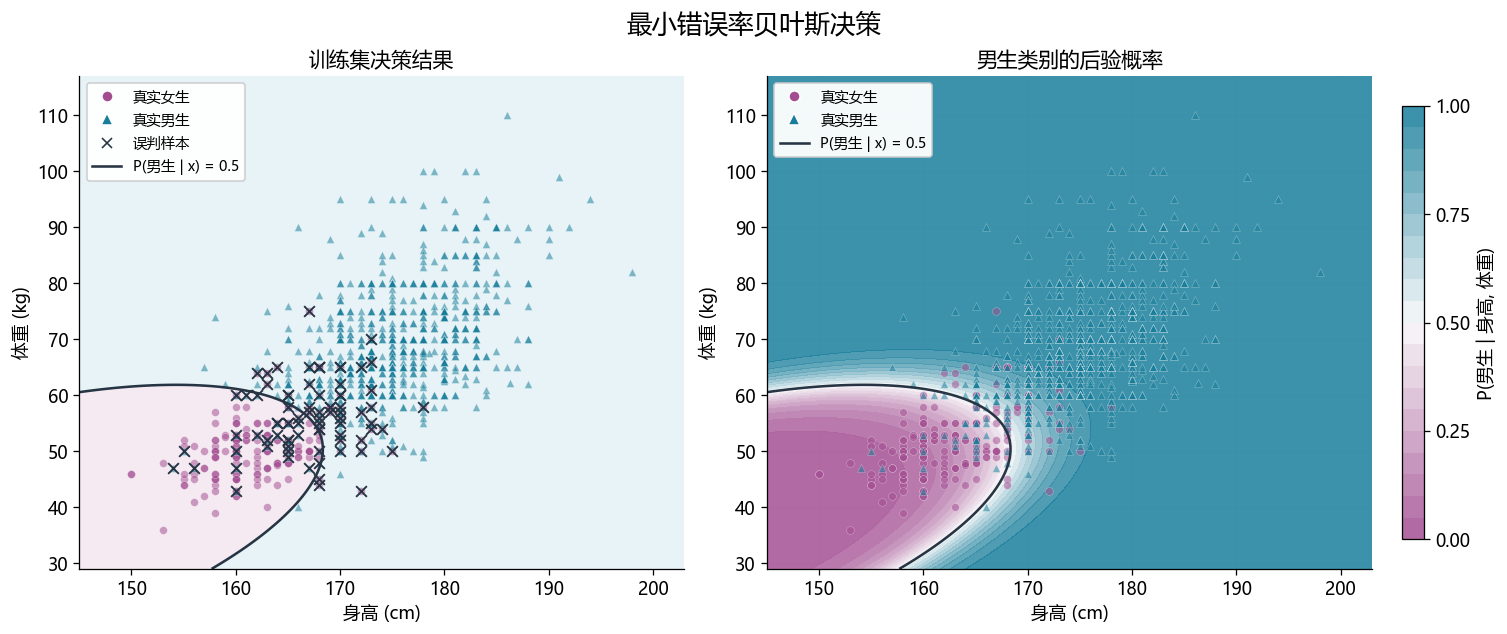

训练集：1013 个样本，正确 931 个，误判 82 个。


In [41]:
def gaussian_logpdf(X, mean, covariance):
    # 二维正态对数密度，保留协方差项。
    X = np.atleast_2d(np.asarray(X, dtype=float))
    delta = X - mean
    sign, log_determinant = np.linalg.slogdet(covariance)
    if sign <= 0:
        raise ValueError("协方差矩阵必须正定。")
    solved = np.linalg.solve(covariance, delta.T).T
    quadratic = np.sum(delta * solved, axis=1)
    d = X.shape[1]
    return -0.5 * (d * np.log(2 * np.pi) + log_determinant + quadratic)

def discriminant_scores(X):
    X = np.atleast_2d(np.asarray(X, dtype=float))
    if X.ndim != 2 or X.shape[1] != 2 or not np.isfinite(X).all():
        raise ValueError("样本应为两个有限数值：[身高(cm), 体重(kg)]。")
    return np.column_stack([
        gaussian_logpdf(X, mle[int(label)]["mean"], mle[int(label)]["covariance"])
        + np.log(mle[int(label)]["prior"])
        for label in CLASSES
    ])

def predict_proba(X):
    scores = discriminant_scores(X)
    shifted = scores - scores.max(axis=1, keepdims=True)
    weights = np.exp(shifted)
    return weights / weights.sum(axis=1, keepdims=True)

def predict(X):
    return CLASSES[np.argmax(discriminant_scores(X), axis=1)]

base_limits = (float(X_train[:, 0].min() - 5), float(X_train[:, 0].max() + 5),
               float(X_train[:, 1].min() - 7), float(X_train[:, 1].max() + 7))

def decision_mesh(points=None):
    xmin, xmax, ymin, ymax = base_limits
    if points is not None:
        points = np.atleast_2d(points)
        xmin, xmax = min(xmin, points[:, 0].min() - 5), max(xmax, points[:, 0].max() + 5)
        ymin, ymax = min(ymin, points[:, 1].min() - 7), max(ymax, points[:, 1].max() + 7)
    heights = np.linspace(max(0.1, xmin), xmax, 260)
    weights = np.linspace(max(0.1, ymin), ymax, 260)
    H, W = np.meshgrid(heights, weights)
    posterior = predict_proba(np.column_stack([H.ravel(), W.ravel()]))[:, 1].reshape(H.shape)
    return H, W, posterior

def draw_decision(ax, samples, labels, title, *, point=None, probability=False, mark_errors=True):
    extent_points = samples if point is None else np.vstack([samples, np.atleast_2d(point)])
    H, W, posterior = decision_mesh(extent_points)
    if probability:
        surface = ax.contourf(H, W, posterior, levels=np.linspace(0, 1, 21), cmap=PROBABILITY_CMAP, alpha=0.88)
    else:
        surface = ax.contourf(H, W, posterior, levels=[0, 0.5, 1], cmap=ListedColormap(REGION_COLORS))
    ax.contour(H, W, posterior, levels=[0.5], colors="#263443", linewidths=1.6)
    handles = []
    for label in CLASSES:
        mask = labels == label
        ax.scatter(samples[mask, 0], samples[mask, 1], s=24, c=COLORS[label],
                   marker="o" if label == 0 else "^", alpha=0.52, edgecolors="white", linewidths=0.25)
        handles.append(Line2D([], [], marker="o" if label == 0 else "^", color="none",
                              markerfacecolor=COLORS[label], markeredgecolor="white", markersize=7,
                              label=f"真实{CLASS_NAMES[label]}"))
    if mark_errors:
        wrong = predict(samples) != labels
        ax.scatter(samples[wrong, 0], samples[wrong, 1], s=45, marker="x", c="#273442", linewidths=1.2)
        handles.append(Line2D([], [], color="#273442", marker="x", linestyle="none", label="误判样本"))
    handles.append(Line2D([], [], color="#263443", lw=1.6, label="P(男生 | x) = 0.5"))
    if point is not None:
        height, weight = np.asarray(point, dtype=float)
        ax.scatter([height], [weight], marker="*", s=270, c="#EEAC38", edgecolors="#202B37", linewidths=1.2, zorder=8)
        ax.annotate(f"({height:g}, {weight:g})", (height, weight), xytext=(9, 12),
                    textcoords="offset points", weight="bold",
                    bbox={"boxstyle": "round,pad=0.25", "fc": "white", "alpha": 0.9, "ec": "none"})
        handles.append(Line2D([], [], color="none", marker="*", markerfacecolor="#EEAC38",
                              markeredgecolor="#202B37", markersize=12, label="输入样本"))
    ax.set(title=title, xlabel="身高 (cm)", ylabel="体重 (kg)",
           xlim=(H.min(), H.max()), ylim=(W.min(), W.max()))
    ax.legend(handles=handles, loc="upper left", framealpha=0.95, fontsize=9)
    return surface

train_prediction = predict(X_train)
train_accuracy = np.mean(train_prediction == y_train)
train_error_count = int(np.sum(train_prediction != y_train))
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), layout="constrained")
draw_decision(axes[0], X_train, y_train, f"训练集决策结果")
surface = draw_decision(axes[1], X_train, y_train, "男生类别的后验概率", probability=True, mark_errors=False)
fig.colorbar(surface, ax=axes[1], label="P(男生 | 身高, 体重)", shrink=0.88, ticks=[0, 0.25, 0.5, 0.75, 1])
fig.suptitle("最小错误率贝叶斯决策", fontsize=16)
show_figure(fig)

print(f"训练集：{len(train)} 个样本，正确 {len(train) - train_error_count} 个，误判 {train_error_count} 个。")

对于作业要求的两个样本，分别计算 $(165,50)$ 和 $(175,50)$ 的类别后验，然后得到最终决策结果。

身高(cm),体重(kg),P(女生 | x),P(男生 | x),判定
165.000000,50.000000,0.745488,0.254512,女生
175.000000,50.000000,0.065977,0.934023,男生


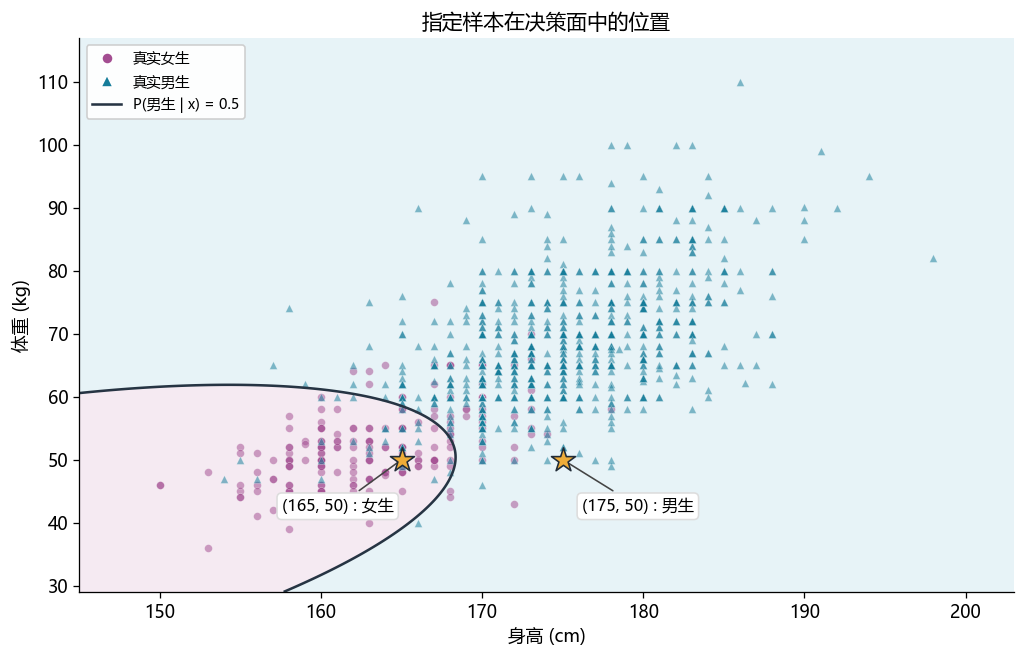

In [42]:
example_X = np.array([[165.0, 50.0], [175.0, 50.0]])
example_probabilities = predict_proba(example_X)
example_labels = predict(example_X)
example_table = pd.DataFrame({
    "身高(cm)": example_X[:, 0], "体重(kg)": example_X[:, 1],
    "P(女生 | x)": example_probabilities[:, 0], "P(男生 | x)": example_probabilities[:, 1],
    "判定": [CLASS_NAMES[label] for label in example_labels],
})
show_table(example_table, 6)

fig, ax = plt.subplots(figsize=(8.8, 5.6), layout="constrained")
draw_decision(ax, X_train, y_train, "指定样本在决策面中的位置", mark_errors=False)
for index, (height, weight) in enumerate(example_X):
    ax.scatter(height, weight, marker="*", s=250, c="#EEAC38", edgecolors="#202B37", zorder=8)
    ax.annotate(f"({height:g}, {weight:g}) : {CLASS_NAMES[example_labels[index]]}",
                (height, weight), xytext=(-75, -32) if index == 0 else (12, -32),
                textcoords="offset points", fontsize=10,
                arrowprops={"arrowstyle": "-", "color": "#444444"},
                bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "#DDDDDD"})
show_figure(fig)

### 6. 测试集评估

测试时使用已经确定的贝叶斯（MLE估计）分类器，报告 Acc、Precision、Recall 和 Macro-F1。
Acc 与 Macro-F1 表示整体表现，Precision、Recall 分别展示女生和男生的结果。

$$\mathrm{Acc}=\frac{\text{正确数}}{N}.$$

$$\mathrm{Precision}_k=\frac{TP_k}{TP_k+FP_k},\qquad
\mathrm{Recall}_k=\frac{TP_k}{TP_k+FN_k}.$$

$$\mathrm{Macro\!\!-\!\!F1}=\frac12\sum_{k=0}^{1}
\frac{2\,\mathrm{Precision}_k\mathrm{Recall}_k}{\mathrm{Precision}_k+\mathrm{Recall}_k}.$$

指标,数值
Acc,90.12%
Macro-F1,83.80%


类别,样本数,Precision,Recall
女生,50,0.7778,0.7000
男生,203,0.9279,0.9507


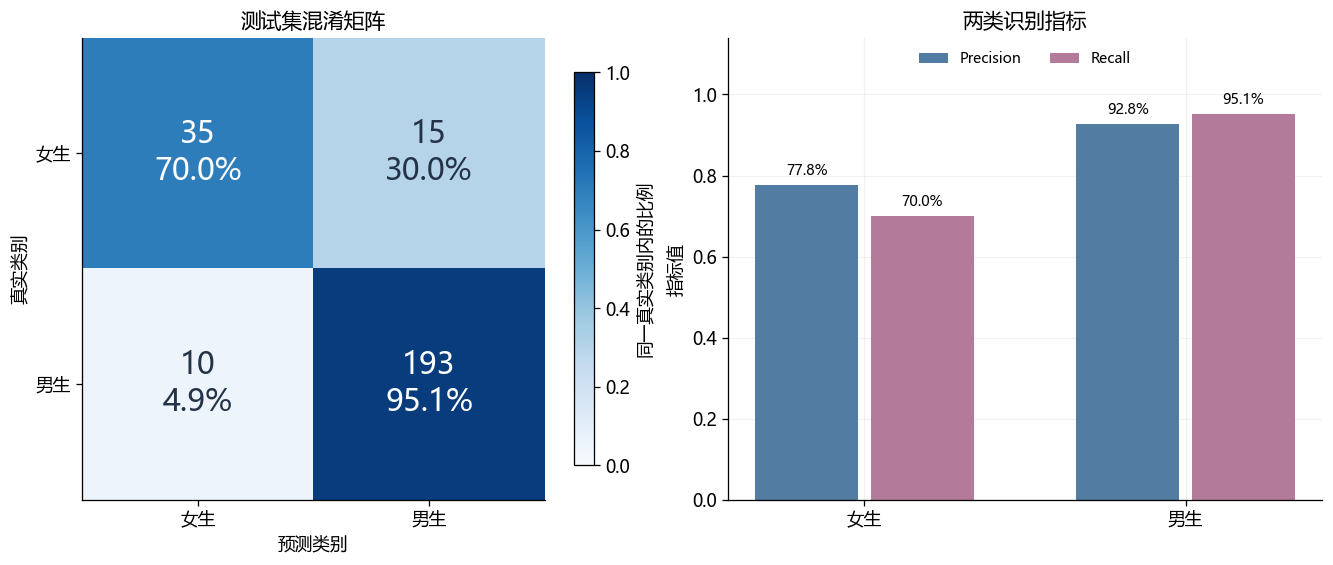

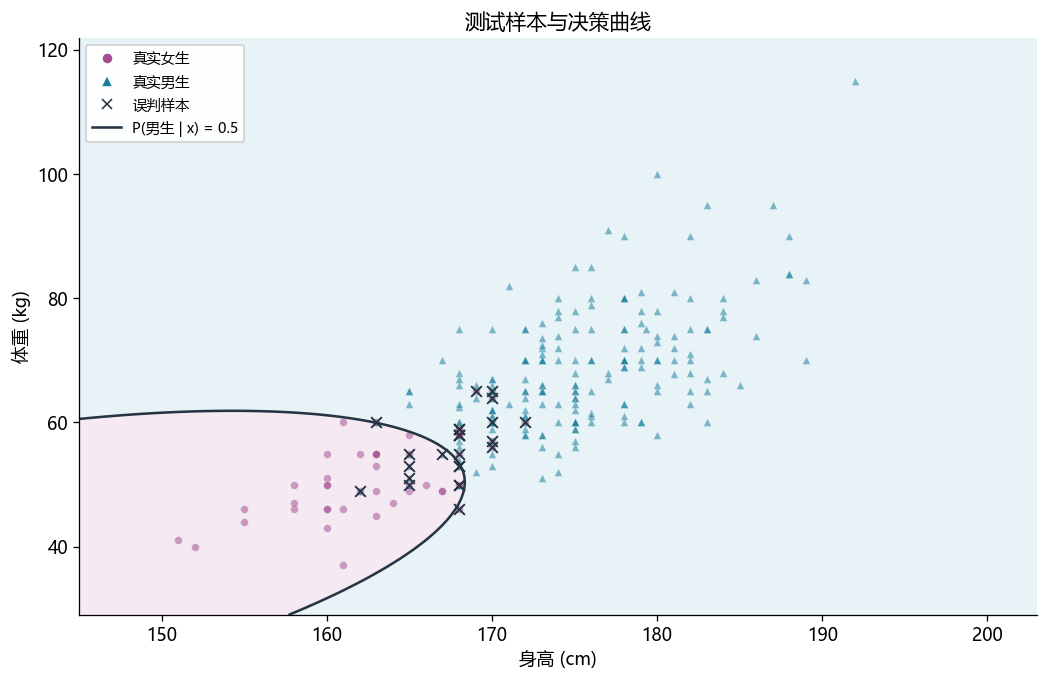

In [48]:
test_prediction = predict(X_test)

# 行=真实标签，列=预测标签；类别顺序 [女生(0), 男生(1)]。
confusion = np.zeros((2, 2), dtype=int)
np.add.at(confusion, (y_test, test_prediction), 1)
true_positive = np.diag(confusion).astype(float)
precision = np.divide(true_positive, confusion.sum(axis=0), out=np.zeros(2), where=confusion.sum(axis=0) != 0)
recall = np.divide(true_positive, confusion.sum(axis=1), out=np.zeros(2), where=confusion.sum(axis=1) != 0)
f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros(2), where=(precision + recall) != 0)
accuracy = float(np.trace(confusion) / confusion.sum())
metrics = {"accuracy": accuracy, "macro_f1": float(f1.mean())}
metric_table = pd.DataFrame({"指标": ["Acc", "Macro-F1"],
                            "数值": list(metrics.values())})
display(metric_table.style.format({"数值": "{:.2%}"}).hide(axis="index"))
per_class_table = pd.DataFrame({"类别": [CLASS_NAMES[k] for k in CLASSES], "样本数": confusion.sum(axis=1),
                               "Precision": precision, "Recall": recall})
show_table(per_class_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
row_normalized = confusion / confusion.sum(axis=1, keepdims=True)
image = axes[0].imshow(row_normalized, cmap="Blues", vmin=0, vmax=1)
for row in range(2):
    for col in range(2):
        axes[0].text(col, row, f"{confusion[row, col]}\n{row_normalized[row, col]:.1%}",
                     ha="center", va="center", fontsize=19,
                     color="white" if row_normalized[row, col] > 0.55 else "#243347")
axes[0].set(xticks=[0, 1], yticks=[0, 1], xticklabels=["女生", "男生"], yticklabels=["女生", "男生"],
            xlabel="预测类别", ylabel="真实类别", title="测试集混淆矩阵")
axes[0].grid(False)
fig.colorbar(image, ax=axes[0], label="同一真实类别内的比例", shrink=0.85)
x = np.arange(2)
for offset, values, title, color in [(-0.18, precision, "Precision", "#537CA3"),
                                      (0.18, recall, "Recall", "#B47A9A")]:
    bars = axes[1].bar(x + offset, values, width=0.32, label=title, color=color)
    axes[1].bar_label(bars, labels=[f"{v:.1%}" for v in values], fontsize=9, padding=4)
axes[1].set(xticks=x, xticklabels=["女生", "男生"], ylim=(0, 1.14), ylabel="指标值", title="两类识别指标")
axes[1].legend(loc="upper center", ncols=2, fontsize=9, frameon=False)
show_figure(fig)

fig, ax = plt.subplots(figsize=(9, 5.8), layout="constrained")
draw_decision(ax, X_test, y_test, f"测试样本与决策曲线")
show_figure(fig)

correct_count = int(np.trace(confusion))

### 7. 可交互预测与绘图

输入身高（cm）和体重（kg）可单独运算后验概率并预测结果。星标为样本在决策面的位置，右侧显示两类后验概率。

In [56]:
def predict_person(height_cm, weight_kg, *, show=True):
    point = np.asarray([height_cm, weight_kg], dtype=float)
    if not np.isfinite(point).all() or np.any(point <= 0):
        raise ValueError("请为身高和体重输入有限的正数。")
    probabilities = predict_proba(point)[0]
    label = int(predict(point)[0])
    result = {"身高(cm)": float(point[0]), "体重(kg)": float(point[1]), "判定": CLASS_NAMES[label],
              "P(女生 | x)": float(probabilities[0]), "P(男生 | x)": float(probabilities[1])}
    if show:
        display(Markdown(f"**判定：{CLASS_NAMES[label]}**。P(女生 | x) = {probabilities[0]:.2%}，P(男生 | x) = {probabilities[1]:.2%}。"))
        fig, axes = plt.subplots(1, 2, figsize=(11.8, 5.1), width_ratios=[2.4, 1], layout="constrained")
        draw_decision(axes[0], X_train, y_train, "输入样本在决策面中的位置", point=point, mark_errors=False)
        bars = axes[1].bar(["女生", "男生"], probabilities, color=[COLORS[0], COLORS[1]], width=0.6)
        axes[1].bar_label(bars, labels=[f"{p:.2%}" for p in probabilities], padding=6)
        axes[1].axhline(0.5, color="#546270", lw=1, linestyle="--")
        axes[1].set(ylim=(0, 1.12), ylabel="后验概率", title="两类后验概率")
        plt.show()
        plt.close(fig)
    return result

height_input = widgets.FloatText(value=165.0, continuous_update=True, description="身高 (cm)", style={"description_width": "80px"},
                                 layout=widgets.Layout(width="235px"))
weight_input = widgets.FloatText(value=50.0, continuous_update=True, description="体重 (kg)", style={"description_width": "80px"},
                                 layout=widgets.Layout(width="235px"))
predict_button = widgets.Button(description="预测并绘图", button_style="info", icon="line-chart",
                                layout=widgets.Layout(width="150px"))
prediction_output = widgets.Output()

def on_predict_clicked(_):
    with prediction_output:
        clear_output(wait=True)
        try:
            predict_person(height_input.value, weight_input.value)
        except (ValueError, TypeError) as error:
            print(str(error))

predict_button.on_click(on_predict_clicked)
display(widgets.VBox([
    widgets.HTML("输入身高（cm）、体重（cm）数值后点击按钮即可生成预测结果。"),
    widgets.HBox([height_input, weight_input, predict_button]), prediction_output,
]))